# Pattern Matching 4 - Video, Matching & Tracking

**Objectives**

* Analyze video sequences
* Match objects between frames for tracking

## Video import

[Download](https://my.pcloud.com/publink/show?code=XZpIUMkZQX7lwSh8BPpO5vF6UWC6xSXgVLRy) the images from the video sequence, and the supervised segmentation ground truth: 

(Reference: http://groups.inf.ed.ac.uk/f4k/PAPERS/VIGTA2012.pdf)

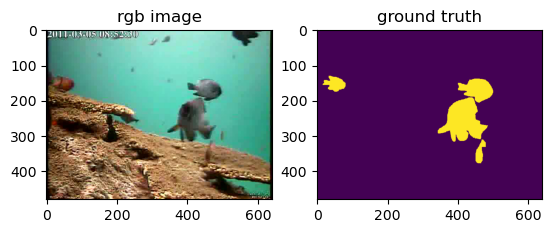

In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from skimage.io import imread
import os

vid_path = '../../extern_data/Video/'
gt_path = '../../extern_data/GroundTruth/'

seq0 = [685,705]
seq1 = [1173,1191]

for no in range(*seq1):
    fid = os.path.join(vid_path,'frame%04d.jpg'%no)
    rgb = imread(fid)    
    
    fid =  os.path.join(gt_path,'%d.png'%no)
    supervision = imread(fid)
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.title('rgb image')
    plt.imshow(rgb)
    plt.subplot(1,2,2)
    plt.imshow(supervision)
    plt.title('ground truth')
    break #stop after one frame for test purpose

## Background image (Video segmentation)

When analyzing video sequences, we can use the *movement of the frame* to help our object segmentation. In this video, our goal is to segment the fish from the background. The background here is the part of the image that doesn't change from frame to frame: detecting the objects can therefore be done using **background subtraction**.

Implement the background subtraction algorithm:

1. Initialize background image: $B_{0} = I_{0}$ where $I_t$ is the image at time $t$ and $B$ is the estimated background. 
1. Update background: $B_{t} = \alpha B_{t-1} + (1-\alpha) I_t$
> What is the purpose of $\alpha$? How can you determine that your background estimation is "stable" and can be used?
1. Subtract background to detect foreground: $F_t = I_t - B_t$
1. Find a good post-processing to clean-up the foreground image. Label the individual objects (fish).
1. Using the supervised part of the sequence, estimate the detection error of your algorithm.
> *Hint: useful metrics for segmentation performance include per-pixel accuracy, precision, recall, or F1-score (DICE). These measures can also be made per-object, which is slightly more difficult to compute but in many applications a better indicator of the actual performance of the algorithm.*

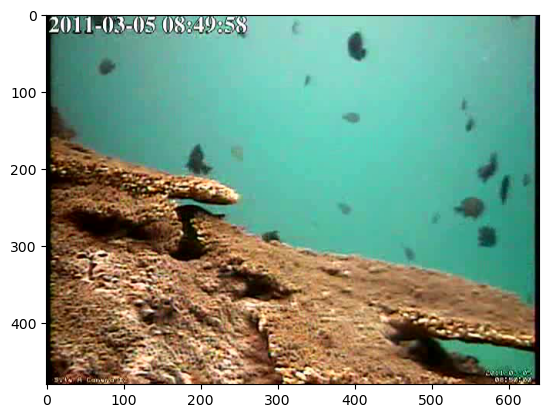

In [21]:

# -- Your code here -- #
B = imread(os.path.join(vid_path, 'frame%04d.jpg'%1))
plt.figure()
plt.imshow(B)
plt.show()

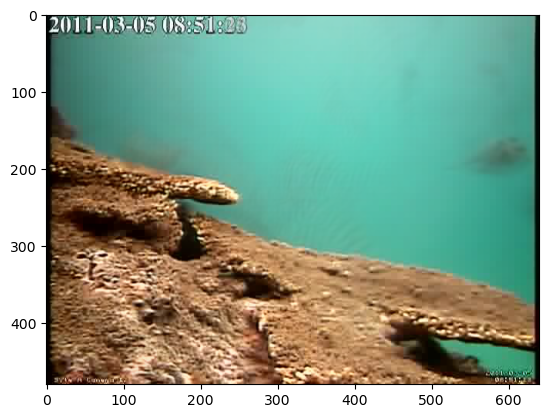

In [22]:
alpha=0.99
for f in range(2, seq0[0]):
    I = imread(os.path.join(vid_path, 'frame%04d.jpg'%f))
    B = alpha*B + (1 - alpha) * I
plt.figure()
plt.imshow(B/255)
plt.show()

0.14315397998060217 321.74127668767204


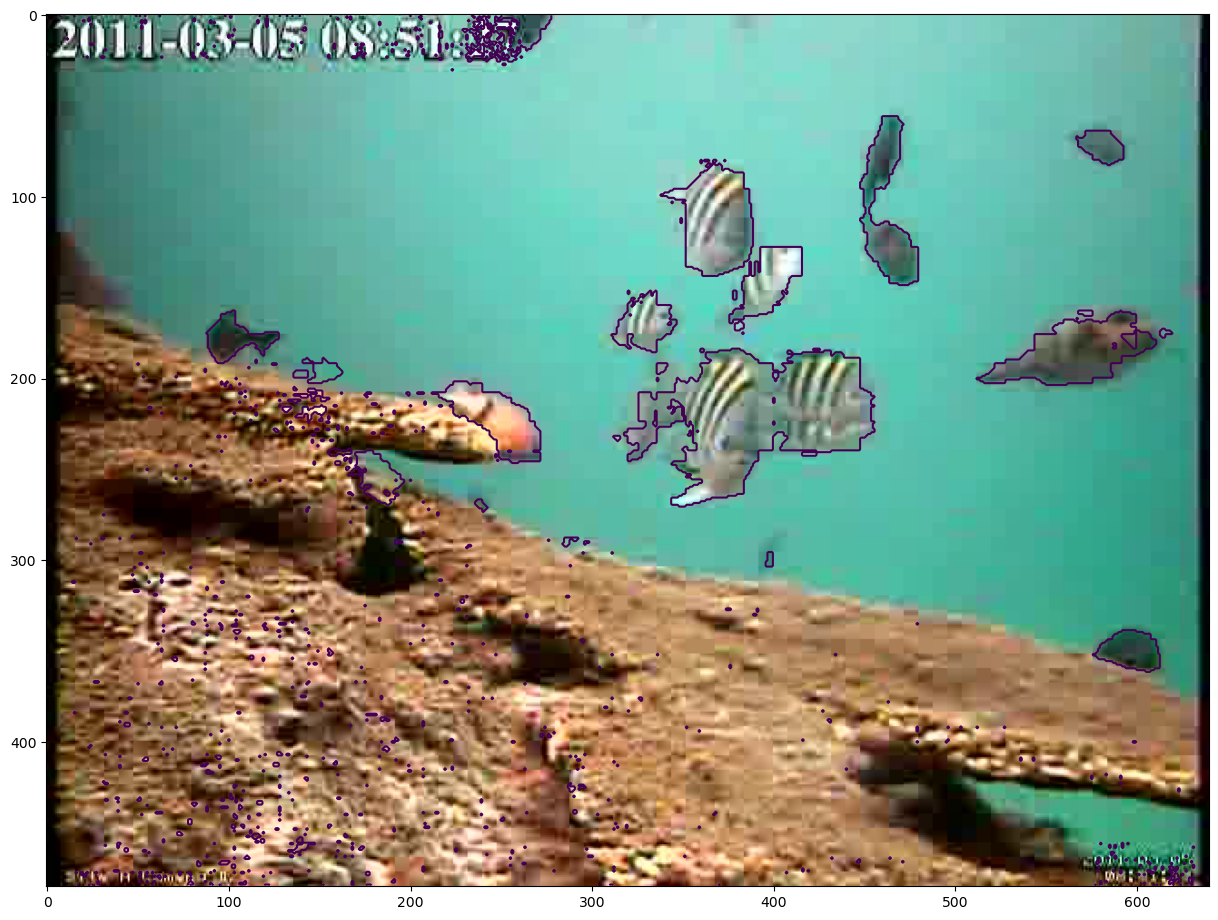

In [23]:
F = np.sqrt(((I - B)**2).sum(axis=2))
print(F.min(), F.max())
fg_mask = F>50
plt.figure(figsize=(15,15))
plt.imshow(I)
plt.contour(fg_mask)
plt.show()

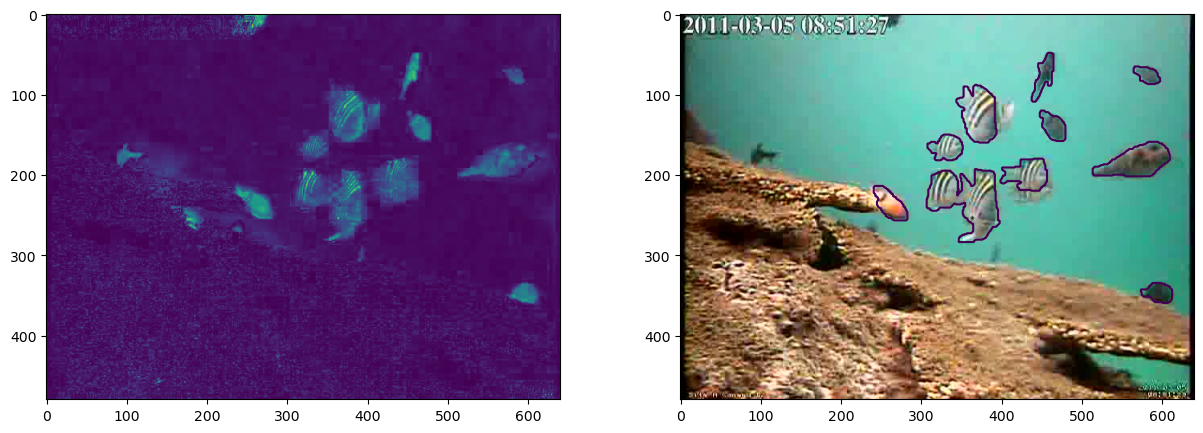

In [24]:
for f in range(*seq0):
    I = imread(os.path.join(vid_path,'frame%04d.jpg'%f))
    F = np.sqrt(((I - B)**2).sum(axis=2))
    S = imread(os.path.join(gt_path,'%d.png'%f)) > 0
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.imshow(F)
    plt.subplot(1,2,2)
    plt.imshow(I)
    plt.contour(S)
    plt.show()
    break

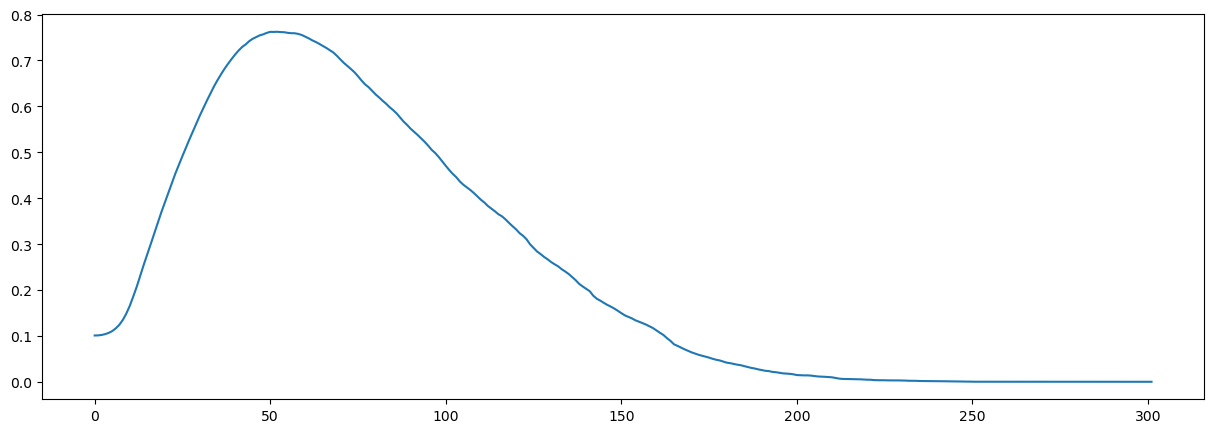

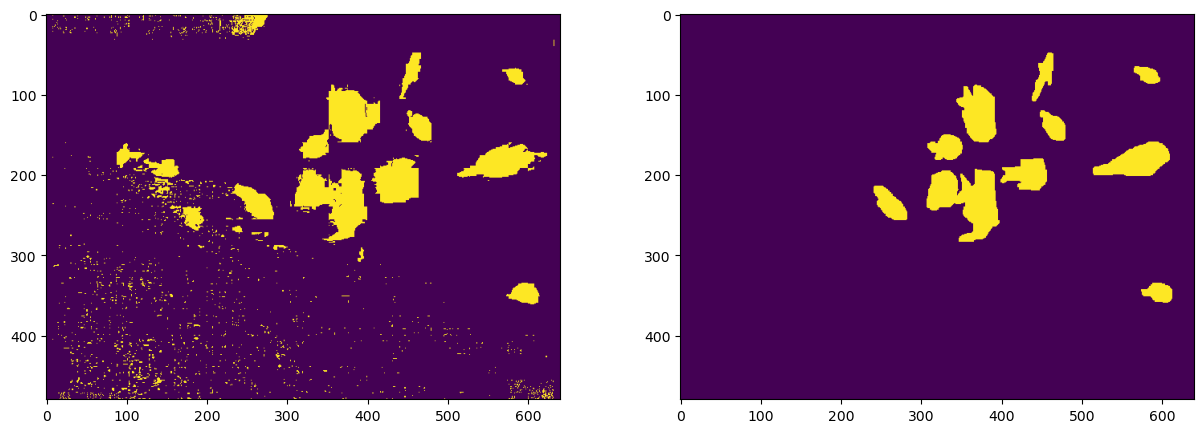

In [25]:
t = 40
P = F > t

def F1(gt, pred):
    intersection = ((gt==1)*(pred==1)).sum()
    return 2*intersection/(gt.sum()+pred.sum())

f1s = []
for t in range(int(F.max())):
    f1s.append(F1(S, F > t))

plt.figure(figsize=(15,5))
plt.plot(f1s)
plt.show()

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(P)
plt.subplot(1,2,2)
plt.imshow(S)
plt.show()

0.8111929135013053


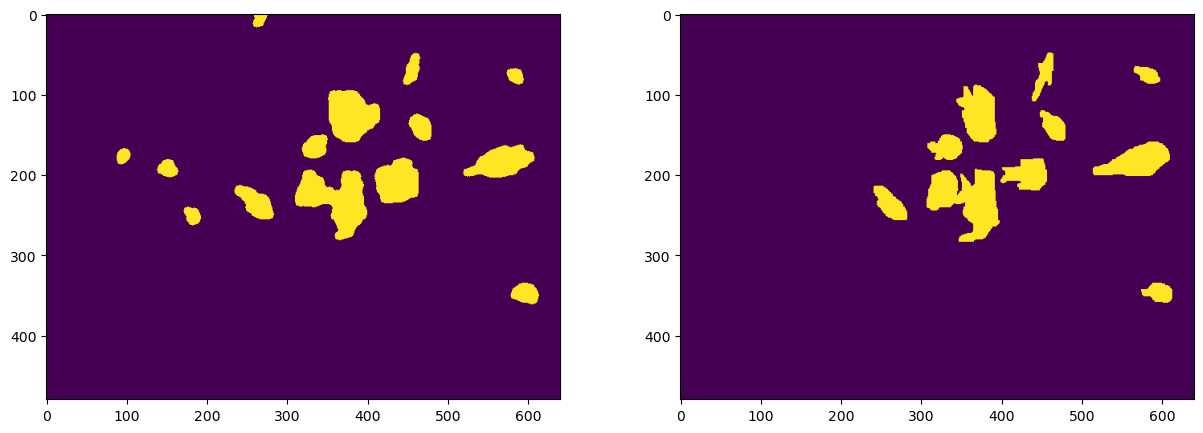

In [26]:
from skimage.morphology import opening, closing, disk

P2 = opening(P, disk(5))
P2 = closing(P2, disk(3))

print(F1(S, P2))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(P2)
plt.subplot(1,2,2)
plt.imshow(S)
plt.show()

## Object tracking

1. Extract interesting features from the detected objects.
1. Suggest a method to recognise and track objects from one frame to the next frame.

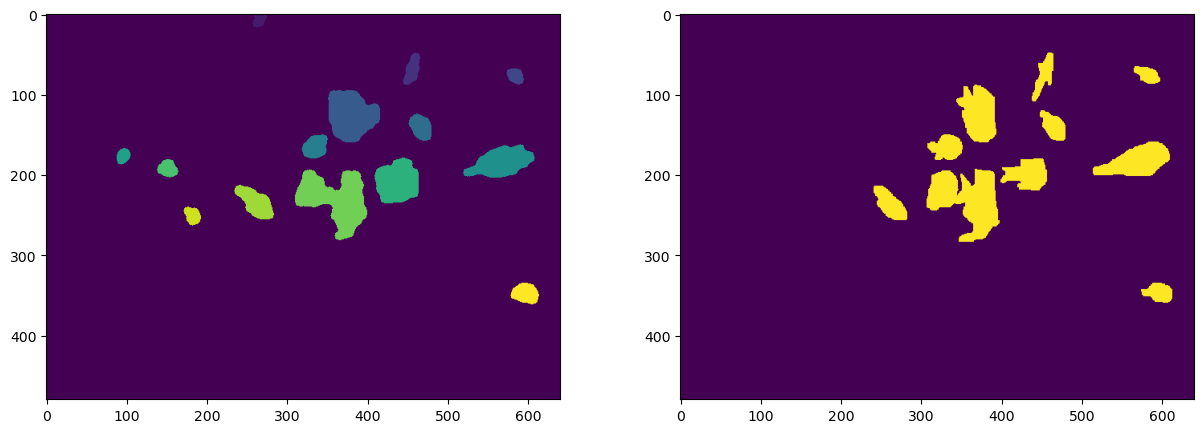

In [27]:

# -- Your code here -- #

from skimage.measure import label

labels = label(P2)
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(labels)
plt.subplot(1,2,2)
plt.imshow(S)
plt.show()


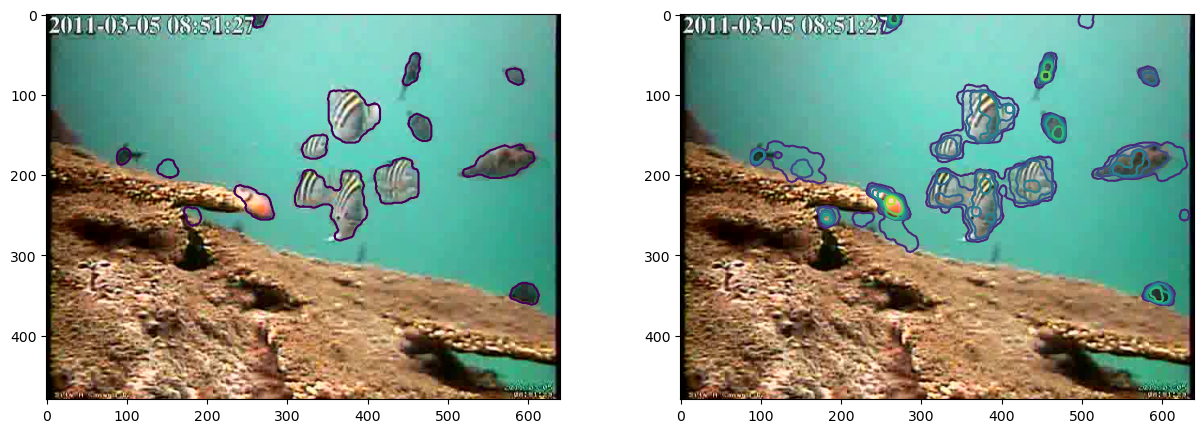

In [28]:
I_next = imread(os.path.join(vid_path,'frame%04d.jpg'%f))
F_next = np.sqrt(((I - B)**2).sum(axis=2))
S_next = imread(os.path.join(gt_path,'%d.png'%f)) > 0

P_next = opening(F_next, disk(5))
P_next = closing(P_next, disk(3))
labels_next = label(P_next)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(I)
plt.contour(P2)
plt.subplot(1,2,2)
plt.imshow(I_next)
plt.contour(P_next)
plt.show()

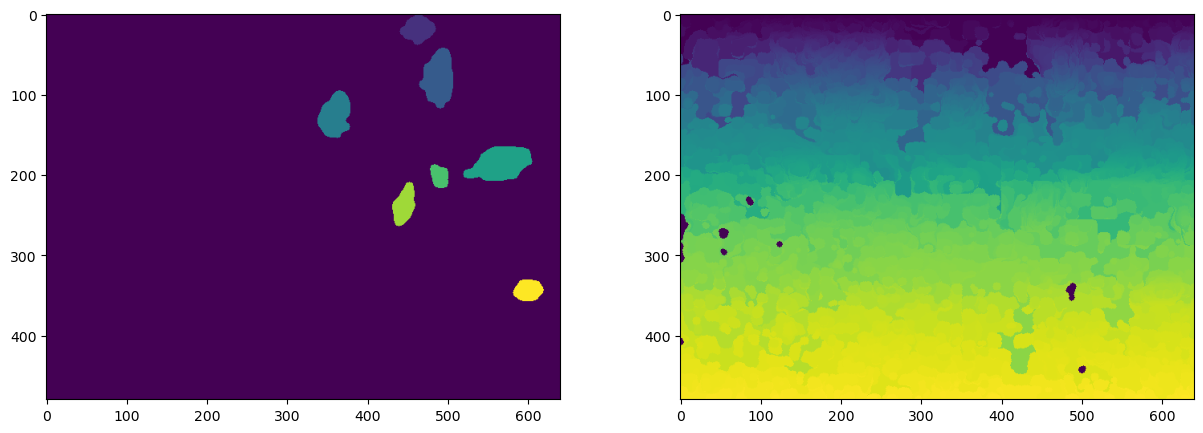

In [29]:
start_frame = seq0[0] + 15
F = imread(os.path.join(vid_path, 'frame%04d.jpg' % start_frame))
F = np.sqrt(((I - B)**2).sum(axis=2))
S = imread(os.path.join(gt_path, '%d.png' % start_frame)) > 0
P = opening(S, disk(5))
P = closing(P, disk(3))
labels = label(P)

f = start_frame
I_next = imread(os.path.join(vid_path, 'frame%04d.jpg' % (f + 1)))
F_next = np.sqrt(((I_next - B)**2).sum(axis=2))
S_next = imread(os.path.join(gt_path, '%d.png' % (f + 1))) > 0

P_next = opening(F_next, disk(5))
P_next = closing(P_next, disk(3))
labels_next = label(P_next)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(labels)
# plt.contour(P)
plt.subplot(1, 2, 2)
plt.imshow(labels_next)
# plt.contour(P_next)
plt.show()


1 [  78   80   81   82   83   84   90   92  168  169  170  171  172  173
  175  206  207  208  209  210  211  254  255  256  257  258  297  298
  299  300  301  302  340  341  342  343  344  345  346  396  397  398
  399  400  401  402  403  409  446  447  448  449  450  451  452  453
  454  455  499  500  501  502  503  504  505  506  507  508  511  543
  544  545  546  547  548  549  550  551  552  553  554  555  556  589
  590  591  592  593  594  595  596  597  598  599  618  619  620  621
  622  623  624  625  626  627  650  651  652  653  654  655  656  657
  658  688  689  690  691  692  693  694  695  696  697  698  699  700
  701  746  747  748  749  750  751  752  753  754  755  756  757  789
  790  791  792  793  794  795  796  797  798  799  800  801  802  803
  804  805  806  835  836  837  838  839  840  841  842  843  844  845
  846  847  848  849  850  851  852  853  877  878  879  880  881  882
  883  884  885  886  887  888  889  890  891  892  927  928  929  930
  93

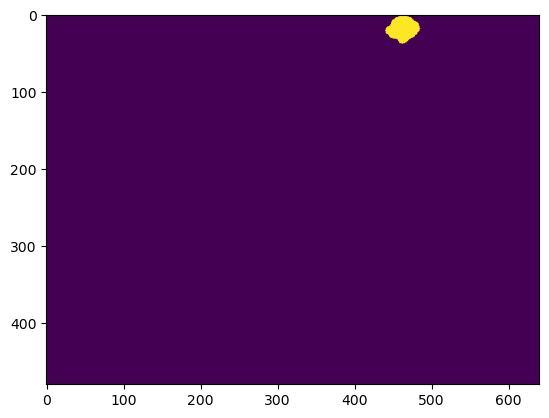

2 [1816 1817 1818 1894 2160 2213 2269 2340 2394 2395 2396 2397 2398 2458
 2459 2460 2509 2510 2511 2512 2513 2514 2573 2574 2575 2576 2577 2578
 2650 2651 2652 2653 2708 2709 2710 2711 2712 2802 2803 2804 2805 2806
 2874 2875 2876 2877 2933 2934 2985 2987 3051 3052 3108 3109 3110 3111
 3112 3113 3114 3115 3173 3174 3175 3176 3177 3225 3226 3227 3228 3303
 3304 3305 3306 3354 3355 3389 3430 3431 3475 3476 3529 3530 3531 3532
 3574 3575 3620 3621 3622 3623 3624 3625 3688 3689 3690 3691 3692 3693
 3694 3695 3696 3745 3746 3747 3779 3782 3783 3784 3785 3821 3822 3823
 3824 3825 3826 3827 3865 3866 3867 3868 3869 3908 3909 3910 3911 3912
 3953 3954 3955 3956 3957 3958 3959 3960 3991 3992 3993 3994 3995 3996
 3997 3998 4037 4038 4039 4040 4041 4042 4043 4044 4083 4084 4085 4086
 4087 4088 4089 4090 4119 4120 4121 4122 4123 4124 4125 4126 4127 4128
 4165 4166 4167 4168 4169 4170 4171 4172 4173 4174 4175 4219 4220 4221
 4222 4223 4224 4225 4226 4227 4228 4229 4274 4275 4276 4277 4278 4279
 428

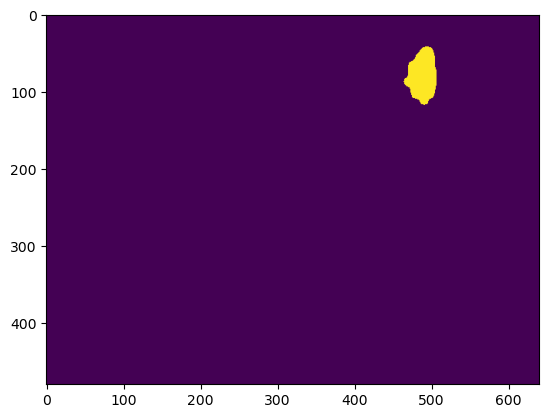

3 [4507 4985 5287 5290 5369 5493 5494 5549 5607 5608 5609 5610 5669 5670
 5671 5672 5673 5725 5726 5727 5728 5781 5782 5783 5784 5837 5838 5839
 5881 5882 5911 5912 5913 5914 5915 5951 5952 5989 5990 5991 6027 6028
 6057 6058 6059 6060 6098 6099 6100 6101 6163 6164 6165 6166 6167 6168
 6225 6226 6227 6228 6265 6266 6267 6268 6269 6270 6309 6310 6311 6312
 6356 6357 6358 6359 6360 6361 6362 6363 6364 6365 6366 6410 6411 6412
 6413 6414 6415 6416 6417 6460 6461 6462 6463 6511 6512 6576 6577 6578
 6579 6580 6581 6620 6621 6622 6623 6624 6625 6626 6627 6628 6663 6664
 6665 6666 6667 6668 6669 6670 6671 6672 6673 6674 6675 6700 6701 6702
 6703 6704 6705 6706 6707 6708 6709 6710 6741 6742 6743 6744 6745 6746
 6747 6748 6788 6789 6790 6791 6821 6822 6823 6824 6825 6853 6854 6855
 6856 6857 6858 6908 6909 6910 6911 6912 6939 6940 6941 6942 6966 6967
 6968 6969 6970 6971 6973 6986 6987 6988 6989 6990 6991 6992 6993 7015
 7016 7017 7018 7019 7020 7021 7022 7023 7043 7044 7045 7046 7047 7048
 704

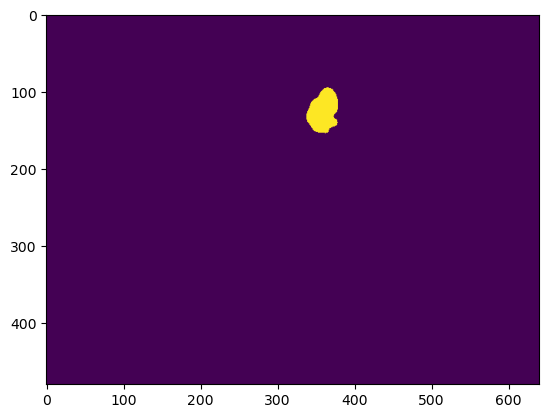

4 [ 7529  7571  7656  7700  7722  7738  7752  7753  7754  7755  7756  7757
  7758  7759  7760  7761  7762  7763  7764  7765  7766  7767  7768  7769
  7791  7792  7793  7794  7795  7796  7797  7798  7799  7800  7801  7802
  7803  7804  7805  7806  7807  7808  7809  7810  7811  7832  7833  7834
  7835  7836  7837  7838  7839  7840  7841  7842  7843  7844  7845  7846
  7847  7872  7873  7874  7875  7876  7877  7878  7879  7880  7881  7882
  7883  7884  7885  7886  7887  7888  7889  7890  7891  7892  7893  7894
  7895  7896  7897  7924  7925  7926  7927  7928  7929  7930  7931  7932
  7933  7934  7935  7936  7937  7938  7939  7940  7941  7942  7943  7944
  7971  7972  7973  7974  7975  7976  7977  7978  7979  7980  7981  7982
  8010  8011  8012  8013  8014  8015  8016  8017  8018  8019  8020  8021
  8022  8023  8024  8025  8026  8027  8062  8063  8064  8065  8066  8067
  8068  8069  8070  8071  8072  8073  8074  8075  8076  8077  8078  8079
  8080  8081  8082  8083  8112  8113  8114  8115 

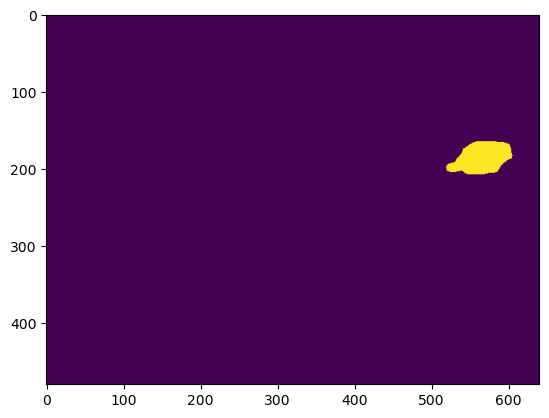

5 [ 8186  8268  8604  9057  9129  9192  9193  9194  9195  9196  9257  9258
  9259  9260  9261  9262  9312  9313  9314  9315  9316  9317  9318  9319
  9320  9321  9322  9378  9379  9380  9381  9382  9383  9384  9385  9386
  9387  9388  9389  9390  9391  9392  9447  9448  9449  9450  9451  9452
  9453  9454  9455  9456  9457  9458  9459  9460  9461  9462  9509  9510
  9511  9512  9513  9514  9515  9516  9517  9518  9519  9573  9574  9575
  9576  9577  9578  9628  9629  9630  9631  9632  9633  9673  9674  9675
  9676  9717  9718  9719  9720  9721  9722  9767  9768  9769  9770  9824
  9825  9826  9827  9828  9889  9890  9891  9892  9958  9959  9960  9961
  9962 10074 10075 10076 10077 10078 10079 10080 10159 10160 10161 10162
 10227 10228 10229 10230 10276 10277 10278 10279 10328 10367 10368 10405]


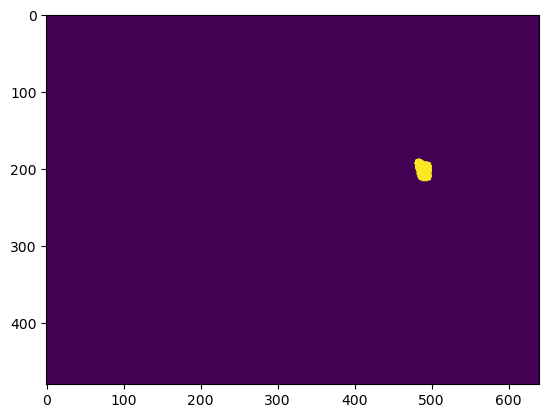

6 [10063 10148 10149 10267 10268 10269 10270 10271 10317 10318 10319 10320
 10358 10359 10395 10396 10427 10428 10429 10460 10461 10462 10463 10464
 10502 10503 10536 10537 10538 10539 10540 10575 10576 10577 10578 10604
 10605 10606 10607 10632 10633 10634 10635 10667 10668 10669 10694 10695
 10696 10697 10698 10775 10776 10777 10778 10779 10780 10819 10820 10871
 10888 10889 10890 10905 10918 10919 10920 10939 10940 10941 10942 10943
 10944 10945 10946 10967 10968 10969 10970 10971 10972 10973 10992 10993
 10994 10995 10996 10997 10998 11013 11014 11015 11016 11017 11018 11019
 11020 11021 11022 11023 11024 11048 11049 11050 11051 11052 11053 11054
 11071 11072 11073 11074 11075 11076 11077 11078 11079 11099 11100 11101
 11102 11103 11104 11105 11106 11137 11138 11139 11140 11141 11142 11143
 11144 11145 11146 11175 11176 11177 11178 11179 11180 11181 11182 11183
 11184 11185 11223 11224 11225 11244 11245 11246 11247 11248 11264 11265
 11283 11284 11285 11309 11310 11311 11312 11335 

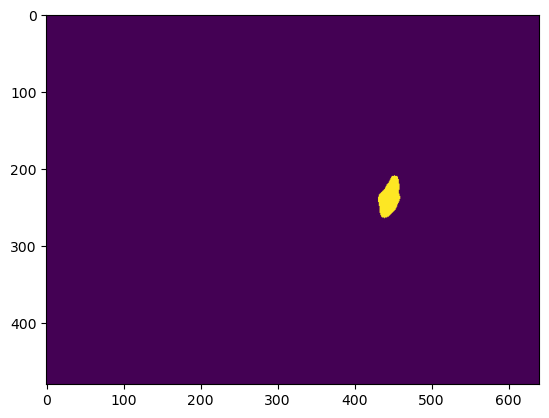

7 [12869 12961 12962 12963 12964 12965 12966 12967 12968 12969 12970 12992
 12993 12994 12995 12996 12997 12998 12999 13000 13001 13031 13032 13033
 13034 13035 13055 13056 13057 13058 13059 13060 13084 13085 13086 13087
 13088 13089 13090 13091 13092 13093 13127 13128 13129 13130 13131 13132
 13133 13134 13135 13136 13137 13138 13139 13140 13141 13142 13143 13173
 13174 13175 13176 13177 13178 13179 13204 13205 13206 13207 13208 13209
 13210 13211 13212 13236 13237 13238 13239 13240 13261 13262 13263 13264
 13265 13266 13286 13287 13288 13289 13290 13291 13305 13306 13307 13308
 13309 13310 13326 13327 13328 13329 13330 13331 13332 13352 13353 13354
 13355 13356 13357 13358 13359 13360 13361 13362 13363 13364 13376 13377
 13378 13379 13380 13381 13382 13397 13398 13399 13400 13419 13420 13435
 13436 13437 13459 13460 13461 13462 13463 13464 13482 13483 13484 13485
 13486 13487 13488 13489 13503 13504 13505 13506 13507 13508 13509 13510
 13511 13530 13531 13532 13533 13534 13535 13536 

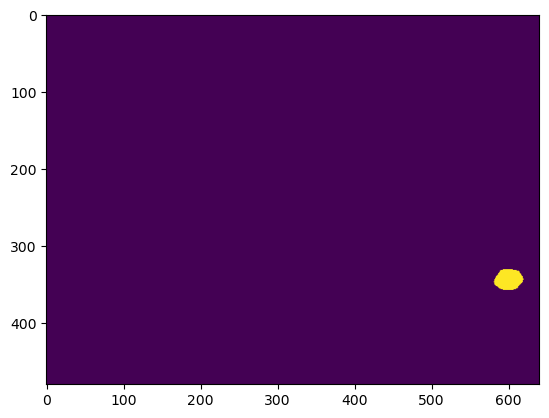

In [30]:
for lab in range(1, labels.max() + 1):
    matching_objects = np.unique(labels_next[labels == lab])
    print(lab, matching_objects)
    plt.figure()
    plt.imshow(labels == lab)
    plt.show()
